# Published profiles and JUMP

An image-based profiling pipeline hands you a table: one row per well or per cell, a few thousand columns of
CellProfiler measurements, and some metadata columns mixed in among them.
{func}`~mantispy.io.read_profiles` turns one or many of those tables into an {class}`~anndata.AnnData`.
It splits the measurements from the metadata and annotates what each feature name encodes.
It handles what differs between real datasets: four spellings of the metadata prefix, missing-value
sentinels, files with different columns, and metadata that only exists in the directory name.

In [1]:
import mantispy as mt

## A dataset

{mod}`mantispy.ds` downloads whole accessions from the
[Cell Painting Gallery](https://github.com/broadinstitute/cellpainting-gallery) {cite:p}`Weisbart_2024`, so there is something real to
read.
This one is kinase inhibitors at a range of doses, eight plates of it.

In [2]:
adata = mt.ds.pki()
adata

AnnData object with n_obs × n_vars = 3072 × 5839
    obs: 'Metadata_plate_map_name', 'Metadata_broad_sample', 'Metadata_mg_per_ml', 'Metadata_mmoles_per_liter', 'Metadata_solvent', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_Barcode', 'Metadata_Supplier', 'Metadata_Supplier_Catalog', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Control', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

Numeric columns that parse as CellProfiler features became the feature matrix, and everything else became `obs`.
Every metadata prefix is normalized to `Metadata_`, and the loader adds the columns an analysis looks for:
`Metadata_Compound`, `Metadata_Concentration`, `Metadata_Control` and `Metadata_Perturbation`.

In [3]:
adata.obs.head()

,Metadata_plate_map_name,Metadata_broad_sample,Metadata_mg_per_ml,Metadata_mmoles_per_liter,Metadata_solvent,Metadata_Plate,Metadata_Well,Metadata_Site_Count,Metadata_Count_Cells,Metadata_Count_CellsIncludingEdges,...,Metadata_Supplier_Catalog,Metadata_pert_type,Metadata_control_type,Metadata_CellCount,Metadata_SiteCount,Metadata_Control,Metadata_Compound,Metadata_Concentration,Metadata_MOA,Metadata_Perturbation
0,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A01,9,1758,1890,...,DMSO,control,negcon,1758.0,9.0,True,DMSO,NaN,NaN,DMSO
1,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A02,9,1941,2137,...,DMSO,control,negcon,1941.0,9.0,True,DMSO,NaN,NaN,DMSO
2,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A03,9,1840,2007,...,DMSO,control,negcon,1840.0,9.0,True,DMSO,NaN,NaN,DMSO
3,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A04,9,1869,2027,...,DMSO,control,negcon,1869.0,9.0,True,DMSO,NaN,NaN,DMSO
4,C-7210-01-CMP-014,NaN,NaN,NaN,DMSO,BR00122970,A05,9,2165,2369,...,DMSO,control,negcon,2165.0,9.0,True,DMSO,NaN,NaN,DMSO


Plates of one screen can disagree on their columns when a channel failed on one of them, so the eight are read
down to the features they share.
That is `on_column_mismatch="intersect"`; the default is to raise instead, so a mismatch is never silent.

In [4]:
adata.obs.groupby("Metadata_Plate", observed=True).size()

Metadata_Plate
BR00122970    384
BR00122971    384
BR00122972    384
BR00122973    384
BR00122974    384
BR00122975    384
BR00122977    384
BR00122978    384
dtype: int64

## What a feature name says

CellProfiler names a feature `<object>_<feature group>_<feature>[_<channel>][_<parameters>]`, and
{func}`~mantispy.io.read_profiles` pulls that apart into `var`.
`Correlation` features measure colocalization between a pair of channels, recorded as a pair such as `AGP|Brightfield`.
`AreaShape` is geometry and carries none.

In [5]:
adata.var.head()

,object,feature_group,feature,channel,scale,angle,gray_levels,radial_bin,params,is_feature
Cells_AreaShape_Area,Cells,AreaShape,Area,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_BoundingBoxArea,Cells,AreaShape,BoundingBoxArea,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_Compactness,Cells,AreaShape,Compactness,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_Eccentricity,Cells,AreaShape,Eccentricity,NaN,NaN,NaN,NaN,NaN,NaN,True
Cells_AreaShape_EquivalentDiameter,Cells,AreaShape,EquivalentDiameter,NaN,NaN,NaN,NaN,NaN,NaN,True


In [6]:
adata.var[adata.var["feature_group"] == "Correlation"].head(3)

,object,feature_group,feature,channel,scale,angle,gray_levels,radial_bin,params,is_feature
Cells_Correlation_Correlation_AGP_BFHigh,Cells,Correlation,Correlation,AGP|BFHigh,NaN,NaN,NaN,NaN,NaN,True
Cells_Correlation_Correlation_AGP_BFLow,Cells,Correlation,Correlation,AGP|BFLow,NaN,NaN,NaN,NaN,NaN,True
Cells_Correlation_Correlation_AGP_Brightfield,Cells,Correlation,Correlation,AGP|Brightfield,NaN,NaN,NaN,NaN,NaN,True


In [7]:
adata.var.groupby(["object", "feature_group"], observed=True).size().sort_values(ascending=False).head(10)

object     feature_group     
Nuclei     Texture               1248
Cytoplasm  Texture               1248
Cells      Texture               1248
Nuclei     Correlation            224
Cytoplasm  Correlation            224
Cells      Correlation            224
           RadialDistribution     207
Cytoplasm  RadialDistribution     207
Cells      Granularity            128
Nuclei     Granularity            128
dtype: int64

A slice of the measurements is then a query on `var` instead of a regex on the names:

In [8]:
dna_intensity = adata[:, (adata.var["channel"] == "DNA") & (adata.var["feature_group"] == "Intensity")]
dna_intensity.shape

(3072, 45)

## Reading your own files

The remaining arguments cover what has differed between datasets:

```python
adata = mt.io.read_profiles(
    sorted(Path("profiles").glob("*/*.parquet")),
    sentinels=-999,                          # values standing for missing, replaced with NaN
    index_columns=("Metadata_Plate", "Metadata_Well"),  # joined with ":" into the observation index
    metadata_columns=("ImageNumber",),       # numeric columns that are not features
    path_columns={"Metadata_Batch": 2},      # metadata read off the file path
    on_column_mismatch="intersect",
)
```

`path_columns` maps a column name to how many directories up from the file to read the name of.
That is how a batch or a plate that exists only in the directory layout gets into `obs`.

Pointed at a directory instead, the same call reads a CellProfiler `ExportToSpreadsheet` run, one row per cell
with every object joined on, or the parquet parts CytoTable writes.

## A first look

These are raw measurements, most of them redundant.
Default feature selection keeps a few hundred, and scaling those is enough for a first look with scanpy:

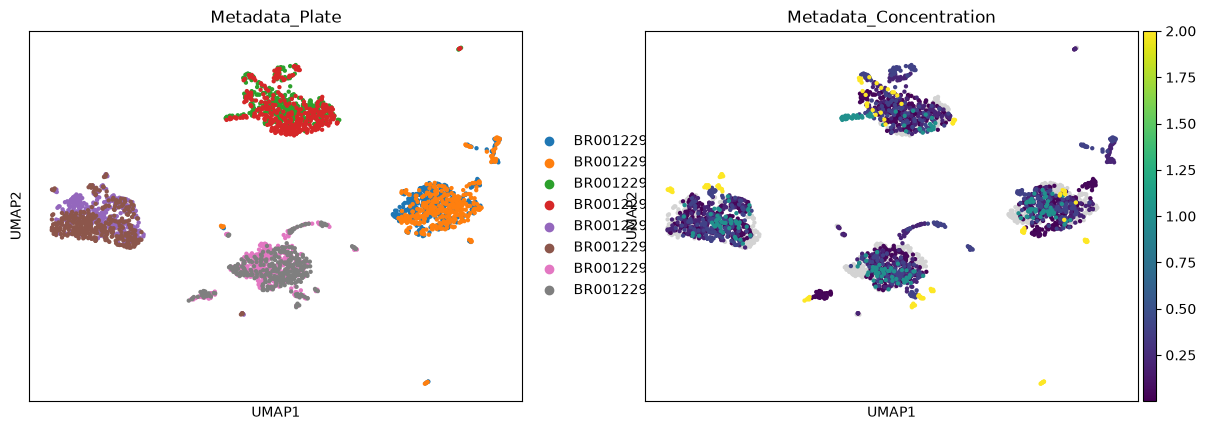

In [9]:
import scanpy as sc

mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)
sc.pp.scale(adata)

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["Metadata_Plate", "Metadata_Concentration"], ncols=2)

The eight plates fall into four clusters of two, and the DMSO wells split among them. All eight share one plate
map, so the clusters come from how the plates were run rather than from what they received, which a real analysis
has to account for before interpreting the rest of the embedding.

## JUMP

A JUMP plate parquet has three metadata columns, source, plate and well, and nothing about what each well
received. {func}`~mantispy.io.read_jump` reads the plates and joins the perturbation from the JUMP metadata
repository, which is what {func}`~mantispy.ds.jump_target2` does for you:

```python
wells = mt.io.read_jump(sorted(Path("jump").glob("*.parquet")), on_column_mismatch="intersect")
```

That annotation names compounds. For the CRISPR plates, `mt.pp.annotate_jump(wells, kind="crispr")` joins the
gene each well targets instead, as {func}`~mantispy.ds.jump_crispr` does.

JUMP calls a participating laboratory a source, `Metadata_Source`. In a CellProfiler export,
`Metadata_Site` is a field of view inside a well, a different thing.

## Working from disk

`mt.io.read(path, backed="r")` leaves `X` in the file. `obs` and `var` are loaded into memory, so metadata,
QC flags and feature selection work as before, and grouped operations read one group at a time.

Backed mode is slower than working in memory, so use it only on data that does not fit.

In [10]:
import tempfile
from pathlib import Path

import numpy as np

path = Path(tempfile.mkdtemp()) / "pki.h5ad"
mt.io.write(mt.ds.pki(), path)

backed = mt.io.read(path, backed="r")
in_memory = mt.io.read(path)

{
    "backed": (backed.isbacked, type(backed.X).__name__),
    "in memory": (in_memory.isbacked, type(in_memory.X).__name__),
    "obs is in memory either way": type(backed.obs).__name__,
}

{'backed': (True, 'Dataset'),
 'in memory': (False, 'ndarray'),
 'obs is in memory either way': 'DataFrame'}

In [11]:
from_disk = mt.pp.normalize(backed, by="Metadata_Plate", reference="negcon", copy=True)
resident = mt.pp.normalize(in_memory, by="Metadata_Plate", reference="negcon", copy=True)

{
    "identical": bool(np.allclose(np.asarray(from_disk.X), np.asarray(resident.X), rtol=1e-6)),
    "largest difference": float(np.abs(np.asarray(from_disk.X) - np.asarray(resident.X)).max()),
}

<path>:1: UserWarning: 133 of 5839 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  from_disk = mt.pp.normalize(backed, by="Metadata_Plate", reference="negcon", copy=True)
<path>:2: UserWarning: 133 of 5839 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to 

{'identical': True, 'largest difference': 0.0}

The results are identical. The backed path reduces group by group while the in-memory path
makes one kernel call, and the test suite asserts they agree to 1e-10.

Functions that rewrite `X` need `copy=True` here. The file is open read-only, so they raise a
clear error instead of failing inside h5py:

In [12]:
try:
    mt.pp.normalize(backed, by="Metadata_Plate")
except ValueError as error:
    print(error)

normalize rewrites X, which a backed object holds read-only on disk. Pass copy=True to get the result in memory, or call adata.to_memory() first.
